In [1]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()


  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`


In [2]:
using Revise
using Statistics
using CairoMakie
includet("analysis.jl")


In [84]:
function fig_path(fig_name::String)
        path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        #"/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

fig_path (generic function with 1 method)

In [104]:
colors = [
                Colors.colorant"#F1C21B",  # IBM Yellow
                Colors.colorant"#D12771",  # IBM Magenta
                Colors.colorant"#009D9A",  # IBM Teal
                Colors.colorant"#0F62FE",  # IBM Blue
                Colors.colorant"#6F6F6F",  # IBM Gray
                Colors.colorant"#FA4D56",  # IBM Red
                Colors.colorant"#24A148",  # IBM Green
        ]

# Link-Degree Skew vs Size for Manifoldlike Simply Connected Datasets

This notebook loads all available `manifoldlike_simply_connected_<size>_10000` statistics files,
computes the skew of the link-degree distribution for each sample, aggregates those skews with
`aggregate_hist_moment`, and plots the mean skew with asymmetric error bars as a function of size.

In [49]:
analysis_root = "/Volumes/Causal Set Silo/causal_sets/analysis"

function manifoldlike_size_path_pairs(root::AbstractString)
    pairs = Tuple{Int,String}[]
    for name in readdir(root)
        m = match(r"^manifoldlike_simply_connected_(\d+)_10000$", name)
        msm = match(r"^manifoldlike_simply_connected_(\d+)_1000$", name)
        isnothing(m) && isnothing(msm) && continue
        size = isnothing(m) ? parse(Int, msm.captures[1]) : parse(Int, m.captures[1])
        path = joinpath(root, name, "statistics.jld2")
        isfile(path) || continue
        push!(pairs, (size, path))
    end
    sort!(pairs; by = first)
    return pairs
end

size_path_pairs = manifoldlike_size_path_pairs(analysis_root)
sizes = first.(size_path_pairs)
paths = last.(size_path_pairs)


deleteat!(sizes, 10)
deleteat!(paths, 10)
deleteat!(sizes, 10)
deleteat!(paths, 10)

sizes


11-element Vector{Int64}:
   256
   300
   400
   512
   600
   700
   800
   900
  1024
  2048
 10000

In [50]:
degree_hists = CausalSetZoology.load_histograms_from_paths(paths, :degree_hist_link)

11-element Vector{Vector{Dict}}:
 [Dict(5 => 28, 16 => 5, 7 => 33, 12 => 10, 8 => 27, 17 => 1, 1 => 1, 4 => 15, 6 => 34, 13 => 8…), Dict(5 => 28, 16 => 1, 7 => 37, 12 => 9, 8 => 32, 4 => 23, 6 => 40, 13 => 7, 11 => 11, 15 => 4…), Dict(5 => 17, 16 => 1, 7 => 31, 12 => 10, 8 => 30, 19 => 1, 4 => 18, 6 => 33, 13 => 4, 11 => 13…), Dict(5 => 26, 16 => 1, 7 => 31, 12 => 5, 8 => 37, 4 => 9, 6 => 45, 13 => 6, 11 => 20, 15 => 3…), Dict(5 => 23, 16 => 2, 20 => 1, 7 => 33, 12 => 8, 8 => 39, 17 => 1, 1 => 1, 4 => 23, 6 => 32…), Dict(5 => 21, 7 => 49, 12 => 9, 8 => 41, 4 => 11, 6 => 37, 13 => 2, 11 => 17, 15 => 3, 2 => 2…), Dict(5 => 26, 16 => 1, 7 => 26, 12 => 14, 8 => 28, 17 => 1, 1 => 2, 4 => 28, 6 => 34, 13 => 10…), Dict(5 => 24, 16 => 3, 7 => 32, 12 => 13, 8 => 41, 4 => 16, 6 => 36, 13 => 6, 11 => 14, 15 => 1…), Dict(5 => 23, 16 => 1, 7 => 32, 12 => 11, 8 => 31, 1 => 1, 4 => 19, 6 => 25, 13 => 10, 11 => 22…), Dict(5 => 22, 7 => 39, 12 => 17, 8 => 36, 4 => 13, 6 => 32, 13 => 7, 11 => 14, 10 => 

In [51]:
skew_stats = [
    CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_skew)
    for hists in degree_hists
]

skew_means = getfield.(skew_stats, :mean)
skew_stds = getfield.(skew_stats, :std)
skew_lows = getfield.(skew_stats, :std_lo)
skew_highs = getfield.(skew_stats, :std_hi)

all(skew_means .> 0) || error("Log-log plot requires positive skew means, but at least one mean skew is non-positive.")

[(; size = sizes[i], mean = skew_means[i], std = skew_stds[i], std_lo = skew_lows[i], std_hi = skew_highs[i]) for i in eachindex(sizes)]

11-element Vector{@NamedTuple{size::Int64, mean::Float64, std::Float64, std_lo::Float64, std_hi::Float64}}:
 (size = 256, mean = 0.34708732028518097, std = 0.18554668354679726, std_lo = 0.16057399223886826, std_hi = 0.1807123613825195)
 (size = 300, mean = 0.33766893832014694, std = 0.173275036294145, std_lo = 0.1514024373752033, std_hi = 0.17049212668073382)
 (size = 400, mean = 0.3234321957696209, std = 0.15564380900234162, std_lo = 0.13641959602573286, std_hi = 0.15178965990581428)
 (size = 512, mean = 0.3105400736582133, std = 0.14029313121017617, std_lo = 0.11865842393528958, std_hi = 0.13677028245406325)
 (size = 600, mean = 0.3024721366662521, std = 0.130958443004544, std_lo = 0.11196474841898382, std_hi = 0.12474700777019593)
 (size = 700, mean = 0.2955045121014693, std = 0.1211374736724073, std_lo = 0.10571724018689727, std_hi = 0.11470992730313717)
 (size = 800, mean = 0.2886715601855037, std = 0.113746063190623, std_lo = 0.09802753756941454, std_hi = 0.10786884230927157)
 (s

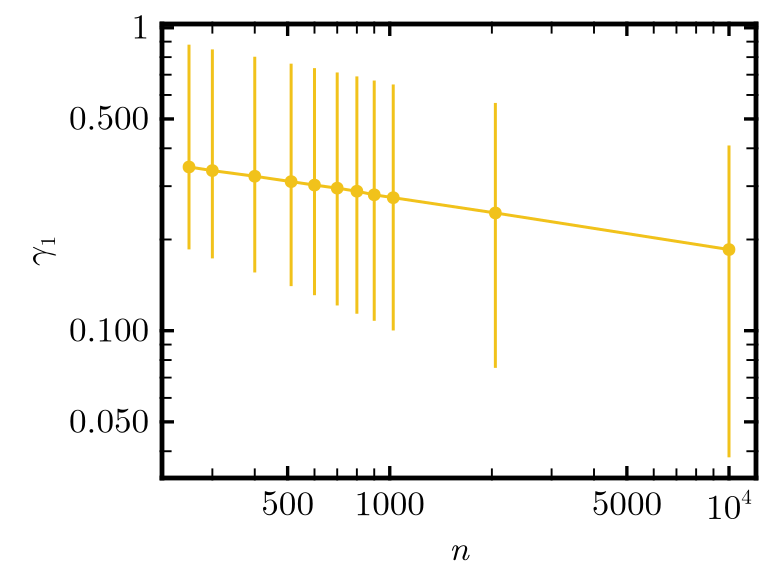

In [53]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
#    title = "Manifoldlike simply connected link-degree skew",
    xscale = log10,
    yscale = log10,
)

errorbars!(ax, sizes, skew_means, skew_means .- skew_stds, skew_means .+ skew_stds,)
scatterlines!(ax, sizes, skew_means; marker = :circle)

fig


In [89]:
decay_exponent = (log(skew_means[end]) - log(skew_means[1])) / (log(sizes[end]) - log(sizes[1]))

-0.17128272289296184

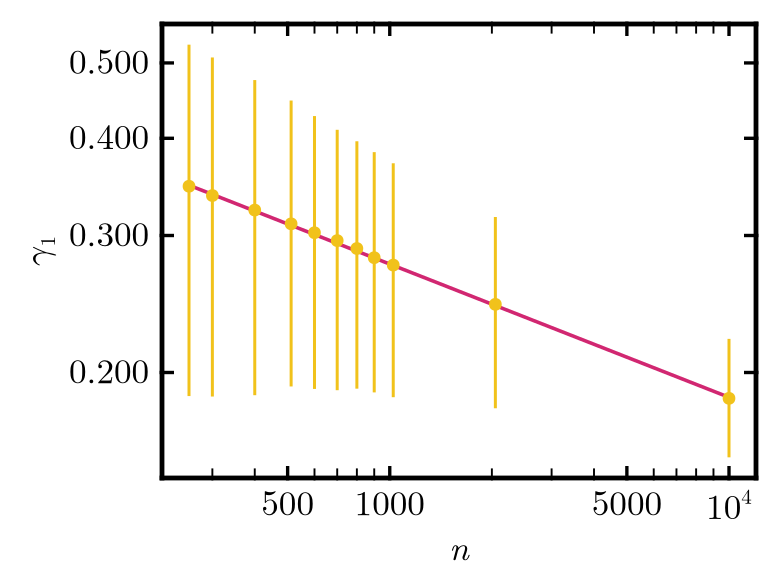

In [108]:
figsize = apply_paper_theme!(; logscale_x = true, logscale_y = true, magnification = 1.2)

fig = Figure(size = figsize)
ax = Axis(
    fig[1, 1];
    xlabel = L"n",
    ylabel = L"\gamma_1",
#    title = "Manifoldlike simply connected link-degree skew",
    xscale = log10,
    yscale = log10,
)

lines!(ax, sizes,0.9 .* sizes .^ decay_exponent, color = colors[2])
errorbars!(ax, sizes, skew_means, skew_lows, skew_highs,)
scatter!(ax, sizes, skew_means; marker = :circle)

save(fig_path("graph_observables/degree_skew_size_scaling.pdf"), fig)

fig